In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

In [2]:
sales = pd.read_csv("C:/Users/user/Downloads/k_circle_sales.csv")

In [3]:
sales.T

,0,1,2,3,4,5,6,7,8,9,...,8513,8514,8515,8516,8517,8518,8519,8520,8521,8522
Item_Identifier,FDA15,DRC01,FDN15,FDX07,NCD19,FDP36,FDO10,FDP10,FDH17,FDU28,...,FDH31,FDA01,FDH24,NCJ19,FDF53,FDF22,FDS36,NCJ29,FDN46,DRG01
Item_Weight,9.3,5.92,17.5,19.2,8.93,10.395,13.65,NaN,16.2,19.2,...,12.0,15.0,20.7,18.6,20.75,6.865,8.38,10.6,7.21,14.8
Item_Fat_Content,Low Fat,Regular,Low Fat,Regular,Low Fat,Regular,Regular,Low Fat,Regular,Regular,...,Regular,Regular,Low Fat,Low Fat,reg,Low Fat,Regular,Low Fat,Regular,Low Fat
Item_Visibility,0.016047,0.019278,0.01676,0.0,0.0,0.0,0.012741,0.12747,0.016687,0.09445,...,0.020407,0.054489,0.021518,0.118661,0.083607,0.056783,0.046982,0.035186,0.145221,0.044878
Item_Type,Dairy,Soft Drinks,Meat,Fruits and Vegetables,Household,Baking Goods,Snack Foods,Snack Foods,Frozen Foods,Frozen Foods,...,Meat,Canned,Baking Goods,Others,Frozen Foods,Snack Foods,Baking Goods,Health and Hygiene,Snack Foods,Soft Drinks
Item_MRP,249.8,48.3,141.6,182.1,53.9,51.4,57.7,107.8,97.0,187.8,...,99.9,57.6,157.5,58.8,178.8,214.5,108.2,85.1,103.1,75.5
Outlet_Identifier,OUT049,OUT018,OUT049,OUT010,OUT013,OUT018,OUT013,OUT027,OUT045,OUT017,...,OUT035,OUT045,OUT018,OUT018,OUT046,OUT013,OUT045,OUT035,OUT018,OUT046
Outlet_Establishment_Year,1999,2009,1999,1998,1987,2009,1987,1985,2002,2007,...,2004,2002,2009,2009,1997,1987,2002,2004,2009,1997
Outlet_Size,Medium,Medium,Medium,NaN,High,Medium,High,Medium,NaN,NaN,...,Small,NaN,Medium,Medium,Small,High,NaN,Small,Medium,Small
Outlet_Location_Type,Tier 2,Tier 2,Tier 2,NaN,Tier 3,Tier 2,Tier 3,Tier 2,NaN,--,...,Tier1,NaN,Tier 2,Tier 2,Tier1,Tier 3,NaN,Tier1,Tier 2,Tier1


In [4]:
sales.shape

(8523, 13)

In [5]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7774 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       6473 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
 12  Profit                     8523 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage:

In [6]:
sales.head().T

,0,1,2,3,4
Item_Identifier,FDA15,DRC01,FDN15,FDX07,NCD19
Item_Weight,9.3,5.92,17.5,19.2,8.93
Item_Fat_Content,Low Fat,Regular,Low Fat,Regular,Low Fat
Item_Visibility,0.016047,0.019278,0.01676,0.0,0.0
Item_Type,Dairy,Soft Drinks,Meat,Fruits and Vegetables,Household
Item_MRP,249.8,48.3,141.6,182.1,53.9
Outlet_Identifier,OUT049,OUT018,OUT049,OUT010,OUT013
Outlet_Establishment_Year,1999,2009,1999,1998,1987
Outlet_Size,Medium,Medium,Medium,NaN,High
Outlet_Location_Type,Tier 2,Tier 2,Tier 2,NaN,Tier 3


In [7]:
num_cols=sales.select_dtypes(include=np.number).columns
num_cols

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales', 'Profit'],
      dtype='object')

In [8]:
cat_cols=sales.select_dtypes(include="object").columns
cat_cols

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [9]:
sales[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Item_Weight,7774.0,11.676740,5.776851,0.00,7.720000,11.800000,16.500000,21.350000
Item_Visibility,8523.0,0.066132,0.051598,0.00,0.026989,0.053931,0.094585,0.328391
Item_MRP,8523.0,140.998838,62.258099,31.30,93.800000,142.700000,185.650000,266.900000
Outlet_Establishment_Year,8523.0,1997.831867,8.371760,1985.00,1987.000000,1999.000000,2004.000000,2009.000000
Item_Outlet_Sales,8523.0,2181.288914,1706.499616,33.29,834.247400,1794.331000,3101.296400,13086.964800
Profit,8523.0,13.414514,1.701840,0.10,13.150000,13.900000,14.300000,24.000000


In [10]:
sales[cat_cols].describe().T

,count,unique,top,freq
Item_Identifier,8523,1559,FDW13,10
Item_Fat_Content,8523,5,Low Fat,5089
Item_Type,8523,16,Fruits and Vegetables,1232
Outlet_Identifier,8523,10,OUT027,935
Outlet_Size,6113,3,Medium,2793
Outlet_Location_Type,6473,8,Tier 2,2793
Outlet_Type,8523,4,Supermarket Type1,5577


In [11]:
sales[num_cols].mean()


Item_Weight                    11.676740
Item_Visibility                 0.066132
Item_MRP                      140.998838
Outlet_Establishment_Year    1997.831867
Item_Outlet_Sales            2181.288914
Profit                         13.414514
dtype: float64

In [12]:
sales[num_cols].median()

Item_Weight                    11.800000
Item_Visibility                 0.053931
Item_MRP                      142.700000
Outlet_Establishment_Year    1999.000000
Item_Outlet_Sales            1794.331000
Profit                         13.900000
dtype: float64

In [13]:
sales[cat_cols].mode()

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDG33,Low Fat,Fruits and Vegetables,OUT027,Medium,Tier 2,Supermarket Type1
1,FDW13,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# EDA Steps
# 1. Univariant Analysis
# 2. Bivariant Analysis
# 3. Missing Value Treatment
# 4. Outlire Treatment(if any)
# 5. Fearture Treatment 
# 6. Scaling and Tranformation

In [15]:
num_cols

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales', 'Profit'],
      dtype='object')

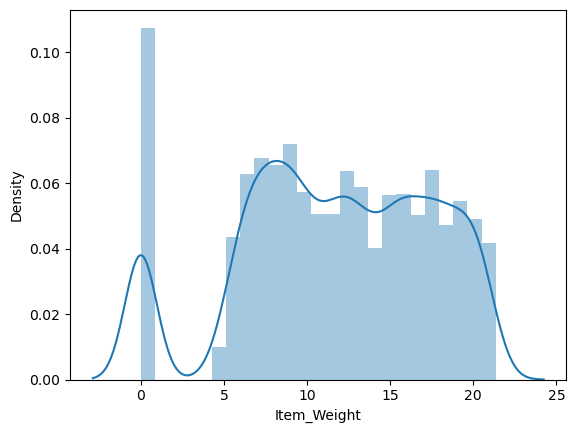

In [16]:
sns.distplot(sales["Item_Weight"])
plt.show()

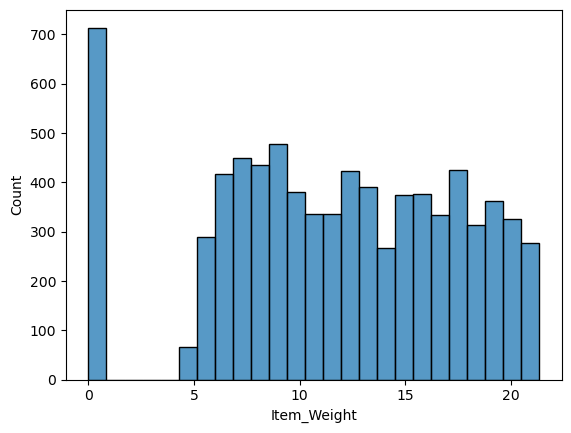

In [17]:
sns.histplot(sales["Item_Weight"])
plt.show()

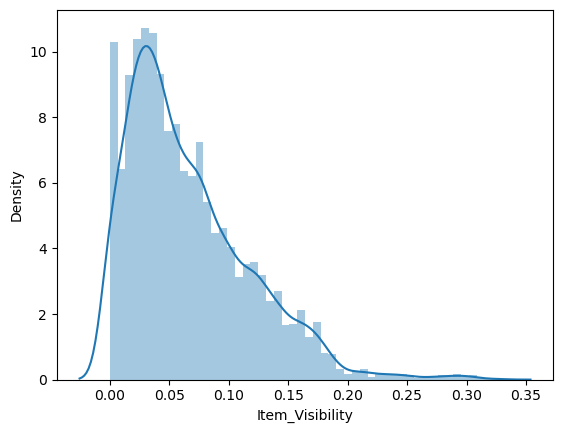

In [18]:
sns.distplot(sales["Item_Visibility"])
plt.show()

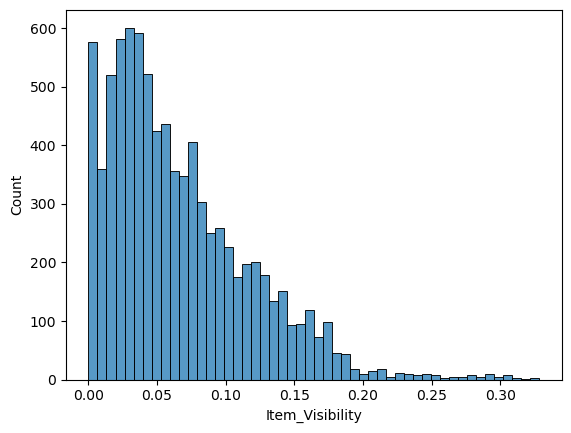

In [19]:
sns.histplot(sales["Item_Visibility"])
plt.show()

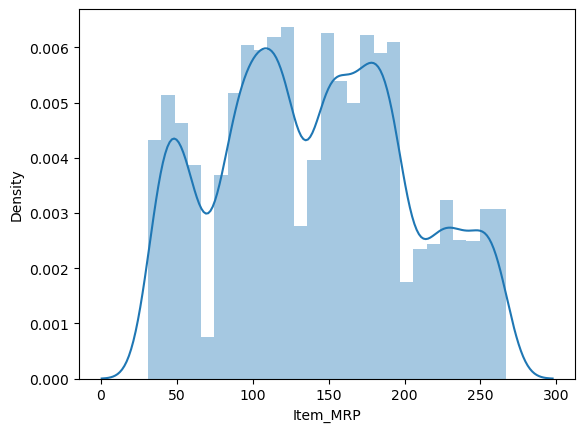

In [20]:
sns.distplot(sales["Item_MRP"])
plt.show()

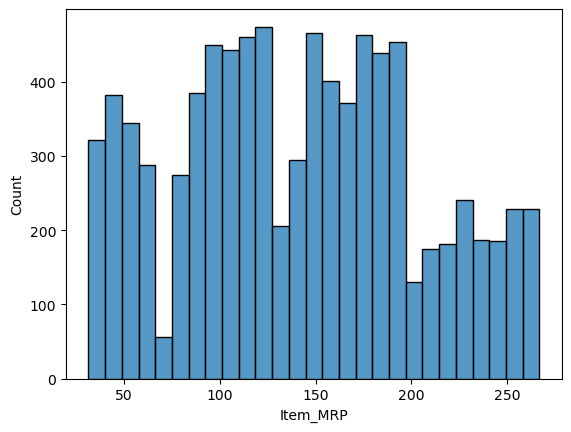

In [21]:
sns.histplot(sales["Item_MRP"])
plt.show()

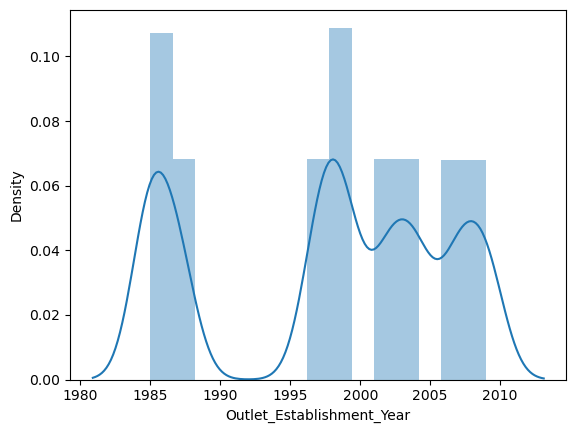

In [22]:
sns.distplot(sales["Outlet_Establishment_Year"])
plt.show()

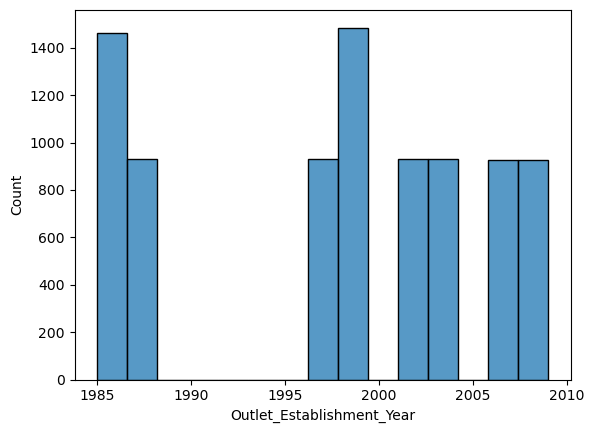

In [23]:
sns.histplot(sales["Outlet_Establishment_Year"])
plt.show()

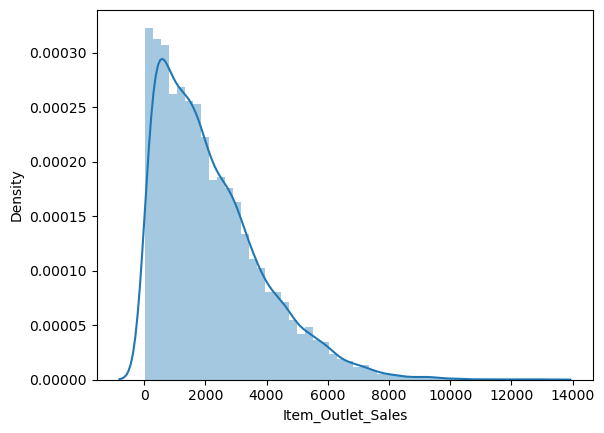

In [24]:
sns.distplot(sales["Item_Outlet_Sales"])
plt.show()

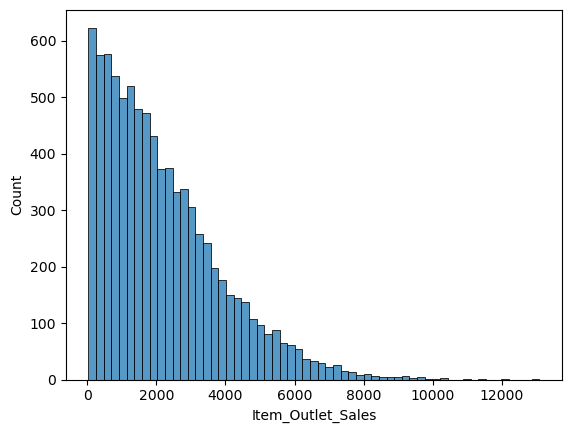

In [25]:
sns.histplot(sales["Item_Outlet_Sales"])
plt.show()

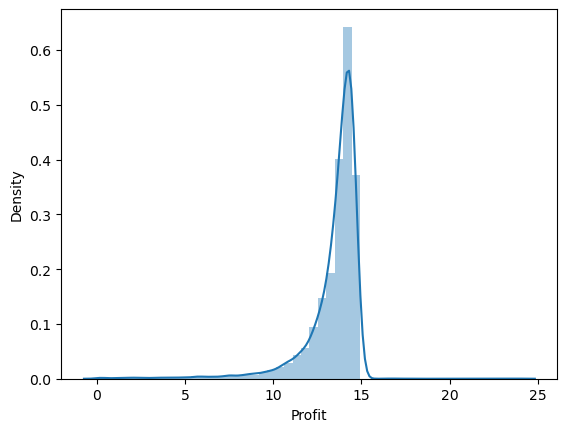

In [26]:
sns.distplot(sales["Profit"])
plt.show()

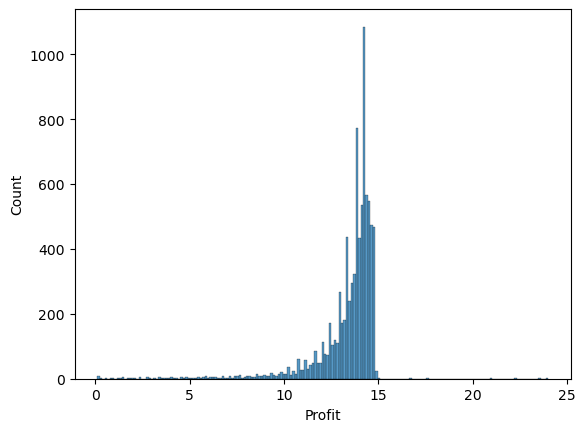

In [27]:
sns.histplot(sales["Profit"])
plt.show()

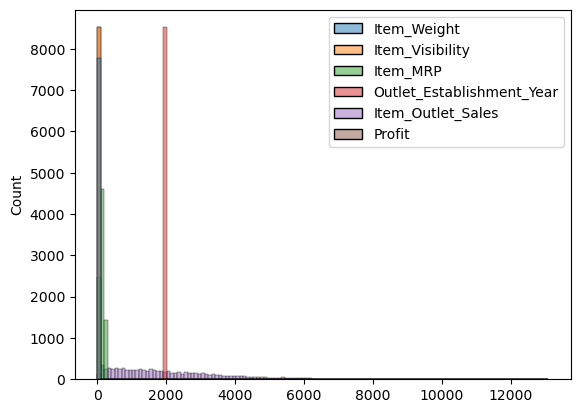

In [28]:
sns.histplot(sales[num_cols])
plt.show()

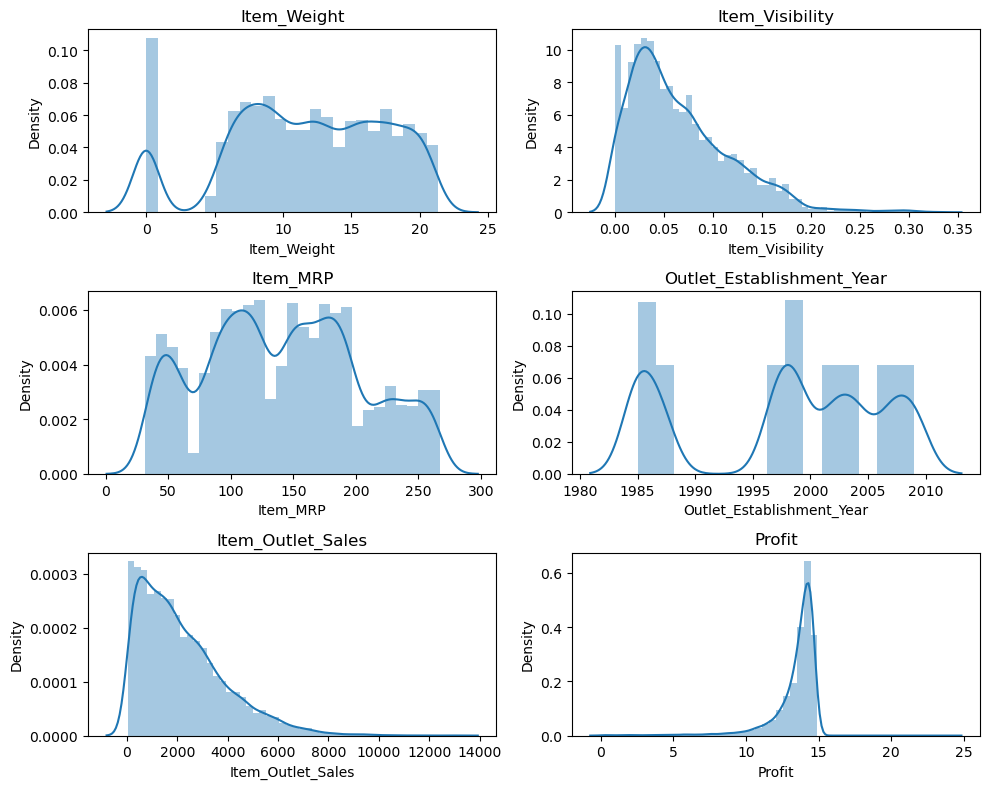

In [29]:
# for num_col
plt.figure(figsize=(10,8))
a=3
b=2
c=1
for i in num_cols:
    plt.subplot(a,b,c)
    sns.distplot(sales[i])
    plt.title(i)
    c+=1
plt.tight_layout()
plt.show()

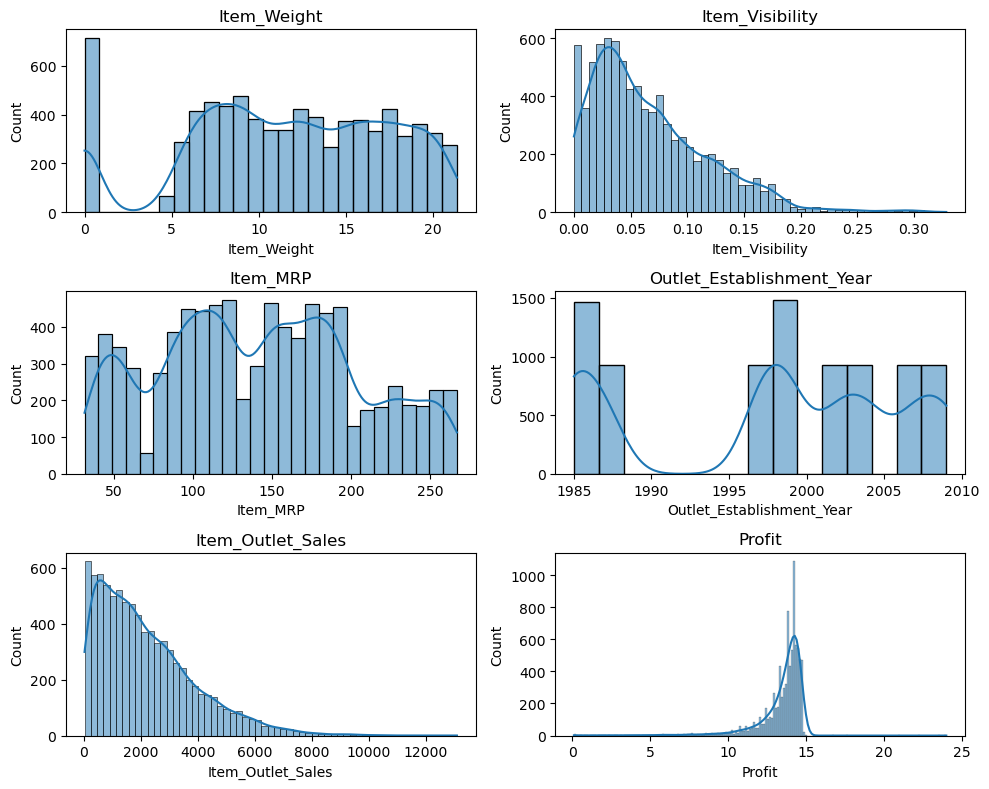

In [30]:
plt.figure(figsize=(10,8))
a=3
b=2
c=1
for i in num_cols:
    plt.subplot(a,b,c)
    sns.histplot(sales[i],kde=True)
    plt.title(i)
    c+=1
plt.tight_layout()
plt.show()

In [31]:
cat_cols

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

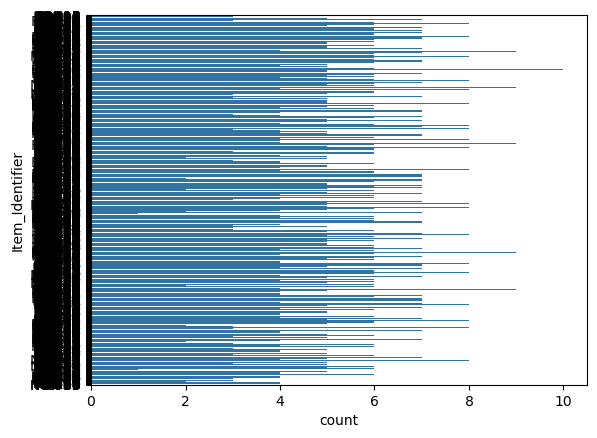

In [32]:
sns.countplot(sales["Item_Identifier"])
plt.show()

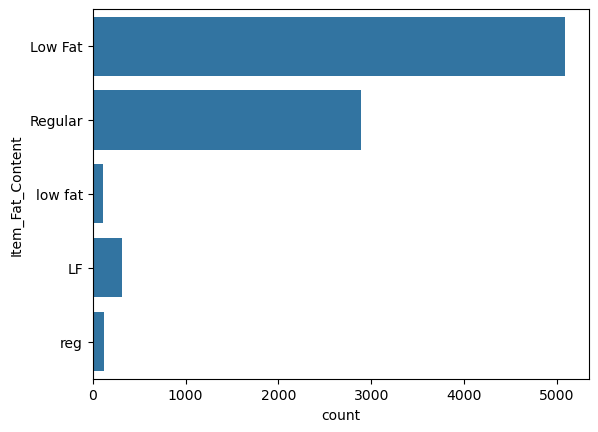

In [33]:
sns.countplot(sales["Item_Fat_Content"])
plt.show()

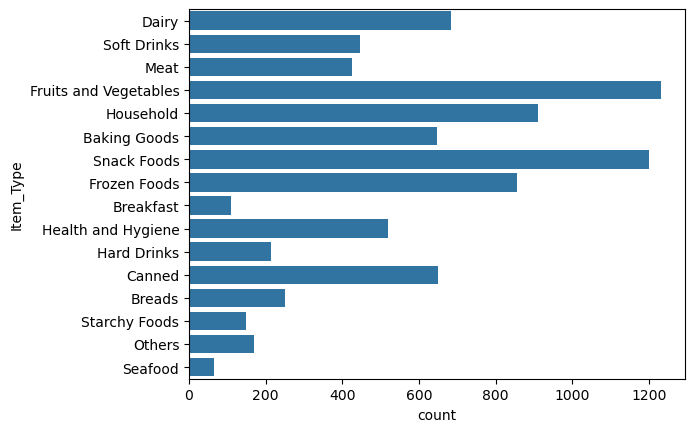

In [34]:
sns.countplot(sales["Item_Type"])
plt.show()

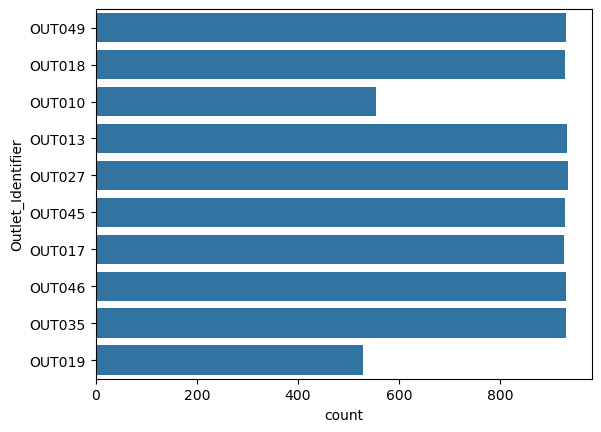

In [35]:
sns.countplot(sales["Outlet_Identifier"])
plt.show()

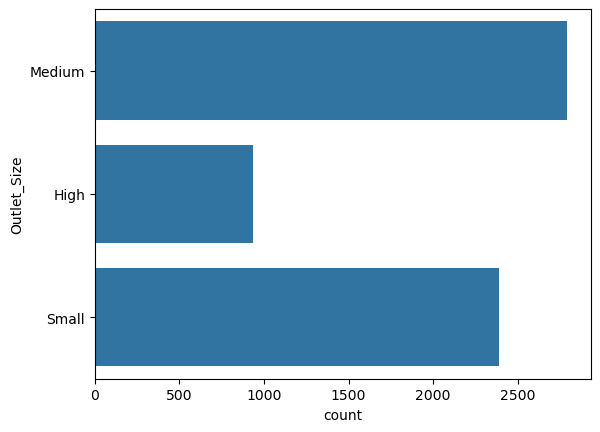

In [36]:
sns.countplot(sales["Outlet_Size"])
plt.show()

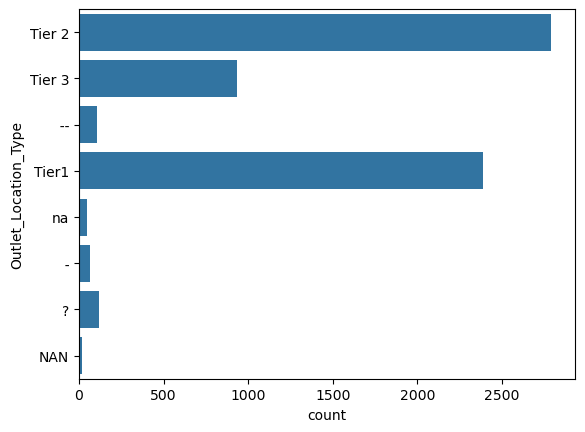

In [37]:
sns.countplot(sales["Outlet_Location_Type"])
plt.show()

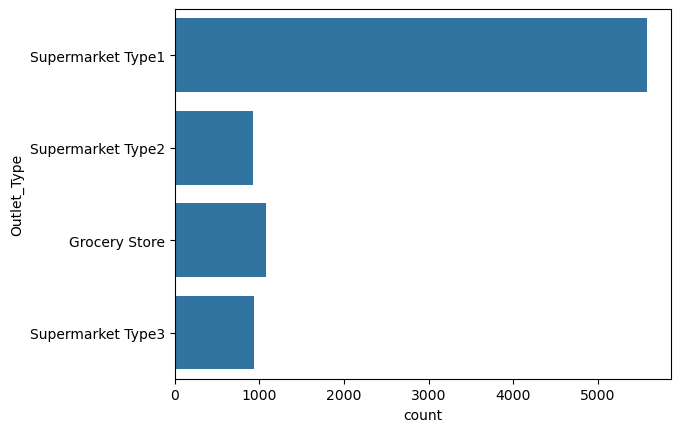

In [38]:
sns.countplot(sales["Outlet_Type"])
plt.show()

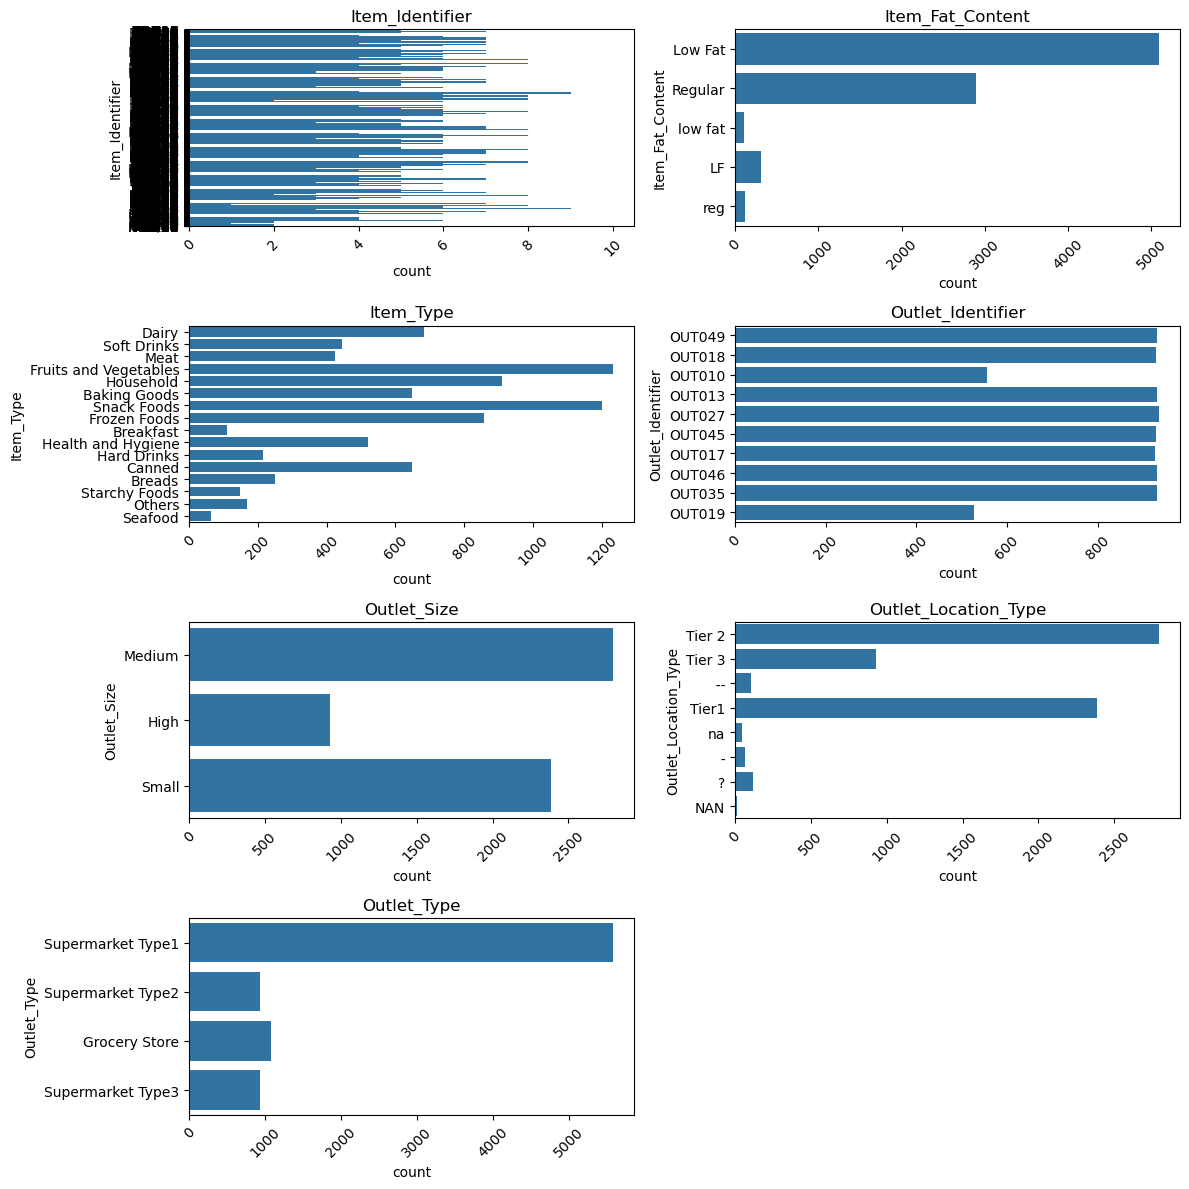

In [39]:
plt.figure(figsize=(12,12))
a=4
b=2
c=1
for i in cat_cols:
    plt.subplot(a,b,c)
    sns.countplot(sales[i])
    plt.title(i)
    plt.xticks(rotation=45)
    c+=1
plt.tight_layout()
plt.show()

In [40]:
sales[num_cols].skew()

Item_Weight                 -0.352215
Item_Visibility              1.167091
Item_MRP                     0.127390
Outlet_Establishment_Year   -0.396641
Item_Outlet_Sales            1.177531
Profit                      -3.379808
dtype: float64

In [41]:
cat_cols

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [42]:
cat_cols=[ 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']
      

In [43]:
cat_cols

['Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

In [44]:
sales['Item_Identifier'].nunique()

1559

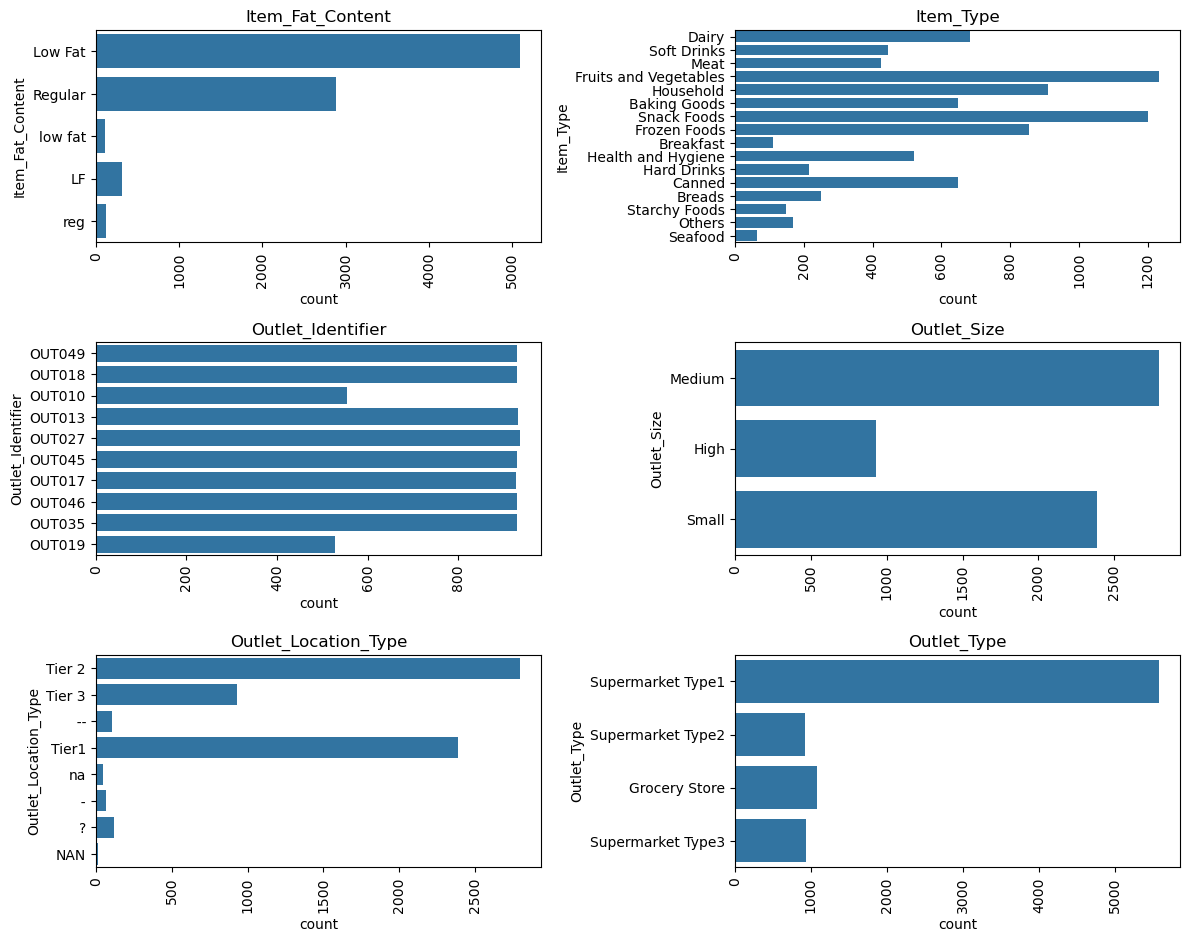

In [45]:
plt.figure(figsize=(12,12))
a=4
b=2
c=1
for i in cat_cols:
    plt.subplot(a,b,c)
    sns.countplot(sales[i])
    plt.title(i)
    plt.xticks(rotation=90)
    c+=1
plt.tight_layout()
plt.show()

In [46]:
num_cols

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales', 'Profit'],
      dtype='object')

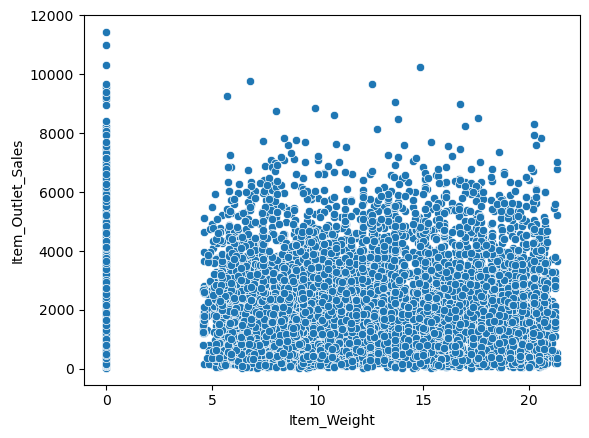

In [47]:
sns.scatterplot(x="Item_Weight",y="Item_Outlet_Sales",data=sales)
plt.show()

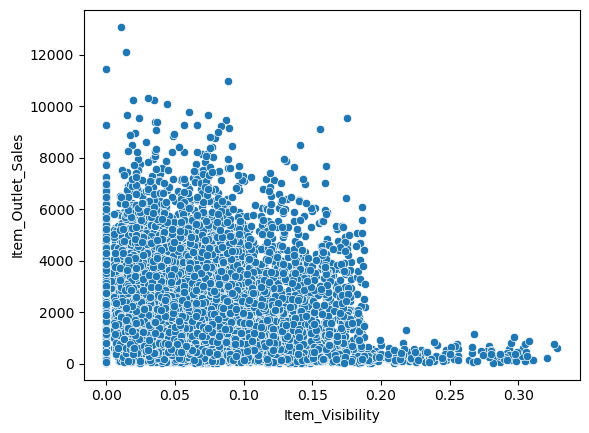

In [48]:
sns.scatterplot(x="Item_Visibility",y="Item_Outlet_Sales",data=sales)
plt.show()

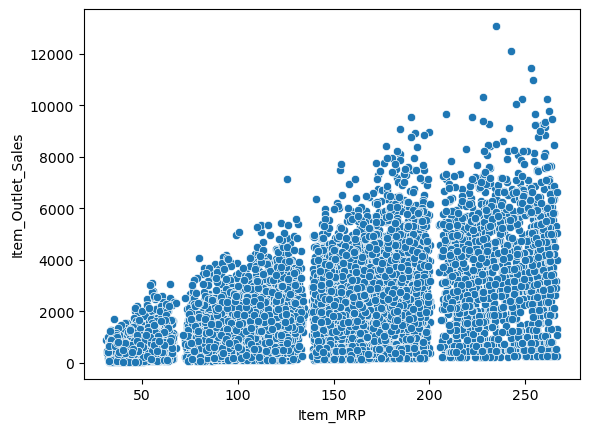

In [49]:
sns.scatterplot(x="Item_MRP",y="Item_Outlet_Sales",data=sales)
plt.show()

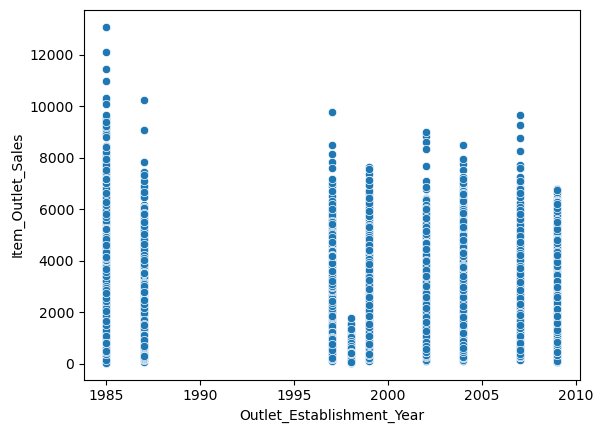

In [50]:
sns.scatterplot(x="Outlet_Establishment_Year",y="Item_Outlet_Sales",data=sales)
plt.show()

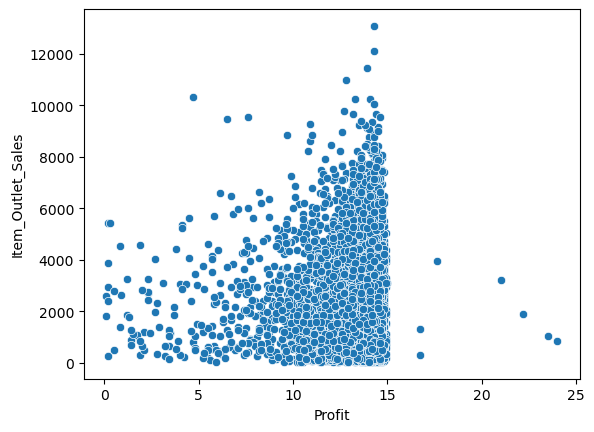

In [51]:
sns.scatterplot(x="Profit",y="Item_Outlet_Sales",data=sales)
plt.show()

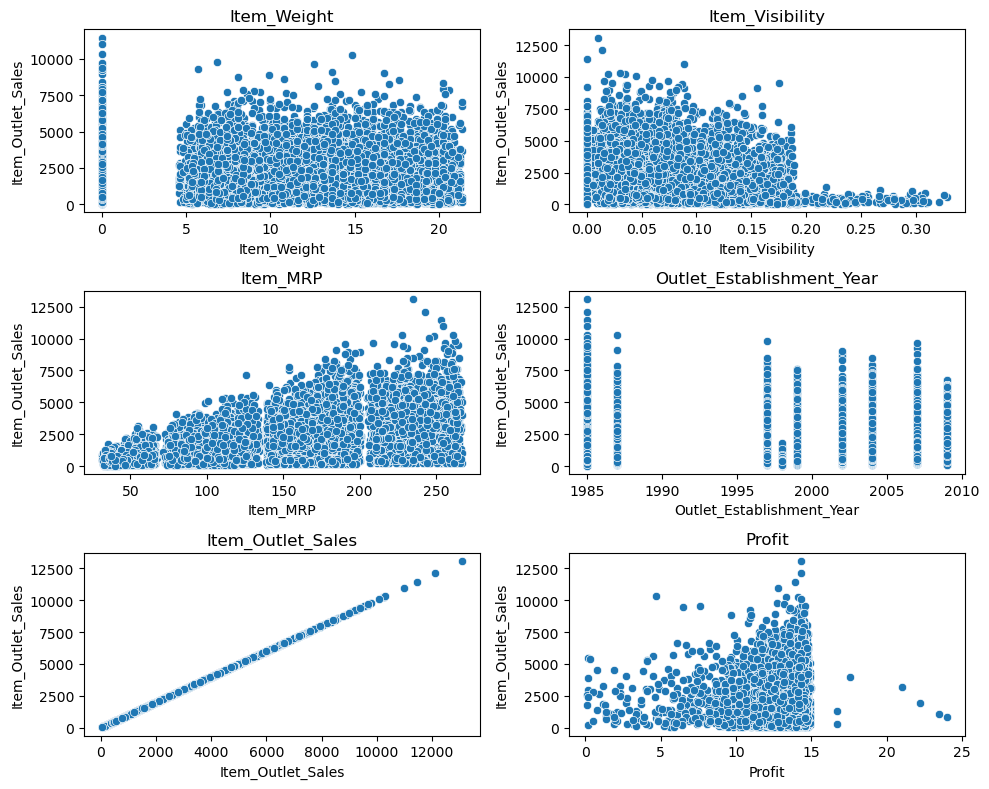

In [52]:
plt.figure(figsize=(10,8))
c=1
for i in num_cols:
    plt.subplot(3,2,c)
    sns.scatterplot(x=sales[i],y=sales["Item_Outlet_Sales"],data=sales)
    plt.title(i)
    c+=1
plt.tight_layout()
plt.show()

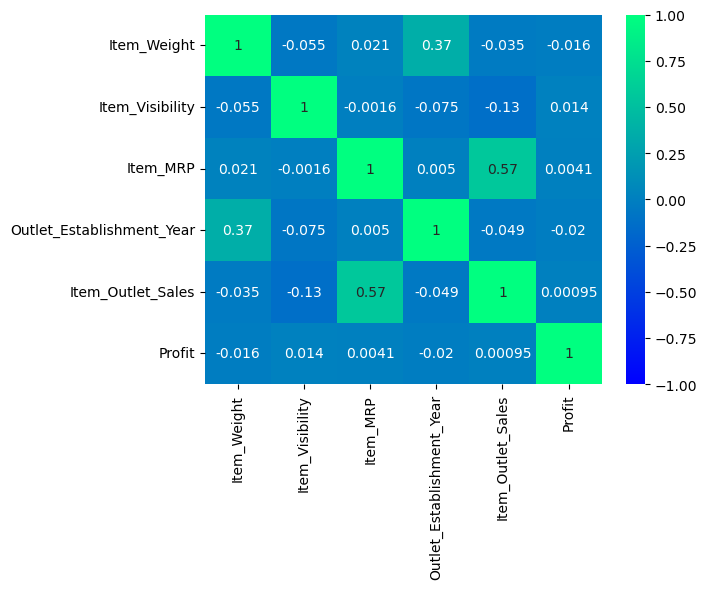

In [53]:
sns.heatmap(sales[num_cols].corr(),annot=True,cmap="winter",vmin=-1,vmax=+1)
plt.show()

In [54]:
#missing values
sales.isnull().sum()

Item_Identifier                 0
Item_Weight                   749
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type         2050
Outlet_Type                     0
Item_Outlet_Sales               0
Profit                          0
dtype: int64

In [55]:
sales[sales["Item_Weight"].isnull()].T

,7,18,21,23,29,136,153,161,168,178,...,8372,8373,8375,8383,8390,8404,8405,8422,8435,8442
Item_Identifier,FDP10,DRI11,FDW12,FDC37,FDC14,FDH35,DRK12,FDR07,NCB30,DRY23,...,FDA01,FDX44,NCM05,NCQ54,NCQ05,DRH39,FDB09,FDD08,FDT48,FDX40
Item_Weight,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Fat_Content,Low Fat,Low Fat,Regular,Low Fat,Regular,Low Fat,Low Fat,Low Fat,Low Fat,Regular,...,Regular,Low Fat,Low Fat,Low Fat,Low Fat,low fat,Low Fat,Low Fat,Low Fat,Low Fat
Item_Visibility,0.12747,0.034238,0.0354,0.057557,0.072222,0.059957,0.041683,0.077367,0.025579,0.191014,...,0.054115,0.042758,0.104784,0.012482,0.037829,0.0,0.100493,0.035183,0.0,0.173324
Item_Type,Snack Foods,Hard Drinks,Baking Goods,Baking Goods,Canned,Starchy Foods,Soft Drinks,Fruits and Vegetables,Household,Soft Drinks,...,Canned,Fruits and Vegetables,Health and Hygiene,Household,Health and Hygiene,Dairy,Fruits and Vegetables,Fruits and Vegetables,Baking Goods,Frozen Foods
Item_MRP,107.8,113.3,144.5,107.7,43.6,165.5,31.3,97.0,198.8,42.1,...,58.5,88.4,266.0,168.3,151.1,76.0,123.1,37.9,196.5,39.9
Outlet_Identifier,OUT027,OUT027,OUT027,OUT019,OUT019,OUT027,OUT027,OUT027,OUT027,OUT019,...,OUT027,OUT027,OUT019,OUT027,OUT019,OUT019,OUT019,OUT027,OUT027,OUT019
Outlet_Establishment_Year,1985,1985,1985,1985,1985,1985,1985,1985,1985,1985,...,1985,1985,1985,1985,1985,1985,1985,1985,1985,1985
Outlet_Size,Medium,Medium,Medium,Small,Small,Medium,Medium,Medium,Medium,Small,...,Medium,Medium,Small,Medium,Small,Small,Small,Medium,Medium,Small
Outlet_Location_Type,Tier 2,Tier 2,Tier 2,Tier1,Tier1,Tier 2,Tier 2,Tier 2,Tier 2,Tier1,...,Tier 2,Tier 2,Tier1,Tier 2,Tier1,Tier1,Tier1,Tier 2,Tier 2,Tier1


In [56]:
sales['Item_Weight'].mean()

np.float64(11.676739773604323)

In [57]:
sales['Item_Weight'].median()

11.8

In [58]:
sales.groupby('Item_Identifier')['Item_Weight'].mean()

Item_Identifier
DRA12    11.600000
DRA24    16.125000
DRA59     7.088571
DRB01     4.926667
DRB13     6.115000
           ...    
NCZ30     6.590000
NCZ41    19.850000
NCZ42    10.500000
NCZ53     7.680000
NCZ54    12.208333
Name: Item_Weight, Length: 1559, dtype: float64

In [59]:
sales["Item_Weight"]=sales.groupby('Item_Identifier')['Item_Weight'].transform(lambda x:x.fillna(x.mean()))
sales['Item_Weight']

0        9.300
1        5.920
2       17.500
3       19.200
4        8.930
         ...  
8518     6.865
8519     8.380
8520    10.600
8521     7.210
8522    14.800
Name: Item_Weight, Length: 8523, dtype: float64

In [60]:
sales[sales['Item_Weight'].isnull()].T

,1922,5022
Item_Identifier,FDK57,FDQ60
Item_Weight,NaN,NaN
Item_Fat_Content,Low Fat,Regular
Item_Visibility,0.079904,0.191501
Item_Type,Snack Foods,Baking Goods
Item_MRP,120.0,121.2
Outlet_Identifier,OUT027,OUT019
Outlet_Establishment_Year,1985,1985
Outlet_Size,Medium,Small
Outlet_Location_Type,Tier 2,Tier1


In [61]:
sales[sales["Outlet_Size"].isnull()]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.1,OUT010,1998,NaN,NaN,Grocery Store,732.3800,13.6
8,FDH17,16.200,Regular,0.016687,Frozen Foods,97.0,OUT045,2002,NaN,NaN,Supermarket Type1,1076.5986,13.0
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8,OUT017,2007,NaN,--,Supermarket Type1,4710.5350,13.6
25,NCD06,13.000,Low Fat,0.099887,Household,45.9,OUT017,2007,NaN,NaN,Supermarket Type1,838.9080,14.3
28,FDE51,5.925,Regular,0.161467,Dairy,45.5,OUT010,1998,NaN,NaN,Grocery Store,178.4344,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8502,NCH43,8.420,Low Fat,0.070712,Household,216.4,OUT045,2002,NaN,NaN,Supermarket Type1,3020.0688,12.5
8508,FDW31,11.350,Regular,0.043246,Fruits and Vegetables,199.5,OUT045,2002,NaN,NaN,Supermarket Type1,2587.9646,10.2
8509,FDG45,8.100,Low Fat,0.214306,Fruits and Vegetables,214.0,OUT010,1998,NaN,NaN,Grocery Store,424.7804,12.8
8514,FDA01,15.000,Regular,0.054489,Canned,57.6,OUT045,2002,NaN,NaN,Supermarket Type1,468.7232,14.0


In [62]:
sales['Outlet_Size'].mode()

0    Medium
Name: Outlet_Size, dtype: object

In [63]:
sales["Outlet_Size"]=sales['Outlet_Size'].transform(lambda x:x.fillna(x.mode()[0]))
sales['Outlet_Size']

0       Medium
1       Medium
2       Medium
3       Medium
4         High
         ...  
8518      High
8519    Medium
8520     Small
8521    Medium
8522     Small
Name: Outlet_Size, Length: 8523, dtype: object

In [64]:
sales[sales['Outlet_Size'].isnull()]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit


In [65]:
sales[sales['Outlet_Location_Type'].isnull()]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.1,OUT010,1998,Medium,NaN,Grocery Store,732.3800,13.6
8,FDH17,16.200,Regular,0.016687,Frozen Foods,97.0,OUT045,2002,Medium,NaN,Supermarket Type1,1076.5986,13.0
25,NCD06,13.000,Low Fat,0.099887,Household,45.9,OUT017,2007,Medium,NaN,Supermarket Type1,838.9080,14.3
28,FDE51,5.925,Regular,0.161467,Dairy,45.5,OUT010,1998,Medium,NaN,Grocery Store,178.4344,14.0
30,FDV38,19.250,Low Fat,0.170349,Dairy,55.8,OUT010,1998,Medium,NaN,Grocery Store,163.7868,11.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8502,NCH43,8.420,Low Fat,0.070712,Household,216.4,OUT045,2002,Medium,NaN,Supermarket Type1,3020.0688,12.5
8508,FDW31,11.350,Regular,0.043246,Fruits and Vegetables,199.5,OUT045,2002,Medium,NaN,Supermarket Type1,2587.9646,10.2
8509,FDG45,8.100,Low Fat,0.214306,Fruits and Vegetables,214.0,OUT010,1998,Medium,NaN,Grocery Store,424.7804,12.8
8514,FDA01,15.000,Regular,0.054489,Canned,57.6,OUT045,2002,Medium,NaN,Supermarket Type1,468.7232,14.0


In [66]:
sales['Outlet_Location_Type'].mode()

0    Tier 2
Name: Outlet_Location_Type, dtype: object

In [67]:
sales['Outlet_Location_Type']=sales['Outlet_Location_Type'].transform(lambda x:x.fillna(x.mode()[0]))
sales['Outlet_Location_Type']

0       Tier 2
1       Tier 2
2       Tier 2
3       Tier 2
4       Tier 3
         ...  
8518    Tier 3
8519    Tier 2
8520     Tier1
8521    Tier 2
8522     Tier1
Name: Outlet_Location_Type, Length: 8523, dtype: object

In [68]:
sales[sales['Outlet_Location_Type'].isnull()]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit


In [69]:
sales.isnull().sum()

Item_Identifier              0
Item_Weight                  2
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
Profit                       0
dtype: int64

In [70]:
weights = np.round(sales.groupby("Item_Identifier")["Item_Weight"].mean(),2).to_dict()
weights

{'DRA12': 11.6,
 'DRA24': 16.12,
 'DRA59': 7.09,
 'DRB01': 4.93,
 'DRB13': 6.12,
 'DRB24': 8.78,
 'DRB25': 12.3,
 'DRB48': 14.36,
 'DRC01': 5.92,
 'DRC12': 17.85,
 'DRC13': 8.26,
 'DRC24': 17.85,
 'DRC25': 5.73,
 'DRC27': 13.8,
 'DRC36': 13.0,
 'DRC49': 8.67,
 'DRD01': 12.1,
 'DRD12': 6.96,
 'DRD13': 15.0,
 'DRD15': 9.09,
 'DRD24': 13.85,
 'DRD25': 5.26,
 'DRD27': 15.0,
 'DRD37': 9.8,
 'DRD49': 9.9,
 'DRD60': 15.7,
 'DRE01': 10.1,
 'DRE03': 19.6,
 'DRE12': 4.59,
 'DRE13': 6.28,
 'DRE15': 10.68,
 'DRE25': 12.28,
 'DRE27': 11.85,
 'DRE37': 13.5,
 'DRE48': 8.43,
 'DRE49': 20.75,
 'DRE60': 7.83,
 'DRF01': 4.24,
 'DRF03': 19.1,
 'DRF13': 12.1,
 'DRF15': 13.76,
 'DRF23': 4.61,
 'DRF25': 6.43,
 'DRF27': 7.65,
 'DRF36': 13.42,
 'DRF37': 17.25,
 'DRF48': 5.73,
 'DRF49': 7.27,
 'DRF51': 15.75,
 'DRF60': 10.8,
 'DRG01': 11.1,
 'DRG03': 14.5,
 'DRG11': 6.38,
 'DRG13': 13.8,
 'DRG15': 6.13,
 'DRG23': 8.88,
 'DRG25': 10.5,
 'DRG27': 8.9,
 'DRG36': 14.15,
 'DRG37': 16.2,
 'DRG39': 14.15,
 'DRG48': 5.

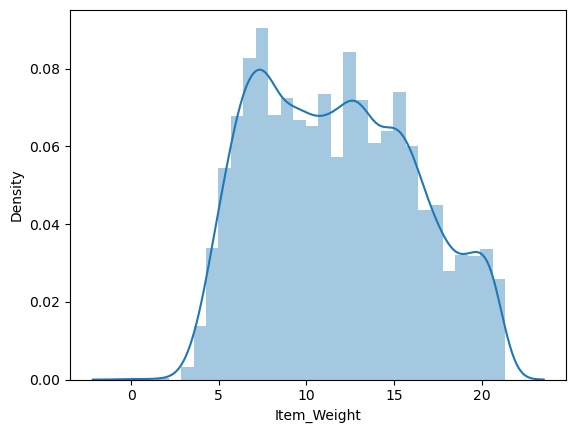

In [71]:
sales["Item_Weight"]=sales['Item_Identifier'].map(weights)
sns.distplot(sales['Item_Weight'])
plt.show()

In [72]:
# featuring Engineering
sales.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3
2,FDN15,14.58,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.1,OUT010,1998,Medium,Tier 2,Grocery Store,732.3800,13.6
4,NCD19,8.93,Low Fat,0.000000,Household,53.9,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,14.1


In [73]:
sales['Item_Identifier'].nunique()

1559

In [74]:
sales['Item_Identifier'][0][:2]

'FD'

In [75]:
items=[]
for i in sales['Item_Identifier']:
    items.append(i[:2])
print(items)

['FD', 'DR', 'FD', 'FD', 'NC', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'NC', 'FD', 'DR', 'FD', 'FD', 'FD', 'NC', 'FD', 'FD', 'NC', 'FD', 'DR', 'FD', 'FD', 'FD', 'NC', 'FD', 'FD', 'DR', 'NC', 'FD', 'DR', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'NC', 'FD', 'FD', 'FD', 'NC', 'FD', 'FD', 'FD', 'NC', 'FD', 'NC', 'DR', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'DR', 'NC', 'FD', 'FD', 'FD', 'FD', 'NC', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'NC', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'DR', 'DR', 'FD', 'NC', 'FD', 'FD', 'FD', 'NC', 'FD', 'FD', 'FD', 'FD', 'DR', 'FD', 'FD', 'FD', 'FD', 'DR', 'DR', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'FD', 'DR', 'FD', 'NC', 'DR', 'FD', 'FD', 'FD', 'FD', 'DR', 'FD', 'DR', 'NC', 'FD', 'NC', 'NC', 'FD', 'FD', 'NC', 'FD', 'FD', 'FD', 'NC', 'NC', 'NC', 'NC', 'NC', 'FD', 'FD', 'FD', 'NC', 'FD', 'NC', 'DR', 'FD', 'FD', 'DR', 'FD', 'NC', 'FD', 'FD', 'DR', 'FD', 'FD', 'FD', 'FD', 'DR', 'FD', 'DR', 'FD

In [76]:
sales['Ids']=items

In [77]:
sales['Ids'].nunique()

3

In [78]:
sales.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit,Ids
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5,FD
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3,DR
2,FDN15,14.58,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5,FD
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.1,OUT010,1998,Medium,Tier 2,Grocery Store,732.3800,13.6,FD
4,NCD19,8.93,Low Fat,0.000000,Household,53.9,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,14.1,NC


In [79]:
sales['Ids'].unique()

array(['FD', 'DR', 'NC'], dtype=object)

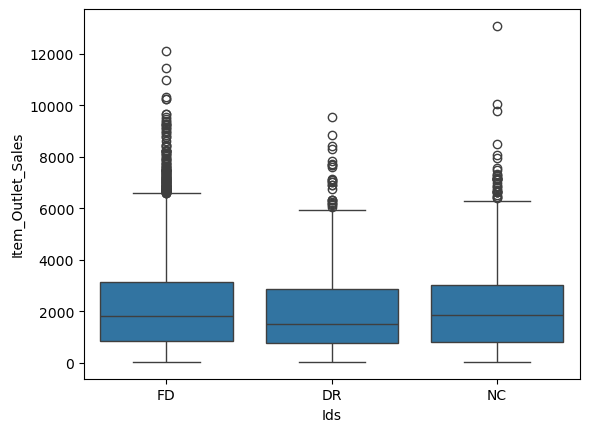

In [80]:
sns.boxplot(x='Ids',y='Item_Outlet_Sales',data=sales)
plt.show()

In [81]:
sales['Item_Fat_Content'].unique()

array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)

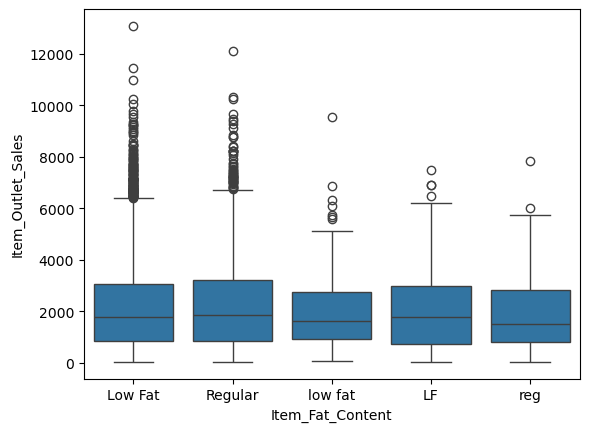

In [82]:
sns.boxplot(x=sales['Item_Fat_Content'],y=sales['Item_Outlet_Sales'],data=sales)
plt.show()

In [83]:
sales["Item_Fat_Content"] = sales["Item_Fat_Content"].replace(
    to_replace=["Low Fat", "Regular", "low fat", "LF", "reg"], 
    value=["Low Fat", "Regular", "Low Fat", "Low Fat", "Regular"]
)

In [84]:
sales.groupby("Ids")["Item_Fat_Content"].describe()

,count,unique,top,freq
Ids,,,,
DR,799,2,Low Fat,728
FD,6125,2,Low Fat,3190
NC,1599,1,Low Fat,1599


In [85]:
sales.loc[sales['Ids']=='NC','Item_Fat_Content']='Non-Edible'

In [86]:
sales.groupby('Ids')['Item_Fat_Content'].describe()

,count,unique,top,freq
Ids,,,,
DR,799,2,Low Fat,728
FD,6125,2,Low Fat,3190
NC,1599,1,Non-Edible,1599


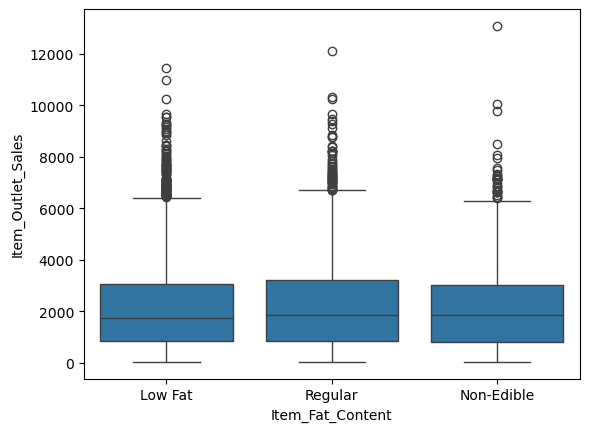

In [87]:
sns.boxplot(x=sales["Item_Fat_Content"],y="Item_Outlet_Sales",data=sales)
plt.show()

In [88]:
sales.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit,Ids
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5,FD
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3,DR
2,FDN15,14.58,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5,FD
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.1,OUT010,1998,Medium,Tier 2,Grocery Store,732.3800,13.6,FD
4,NCD19,8.93,Non-Edible,0.000000,Household,53.9,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,14.1,NC


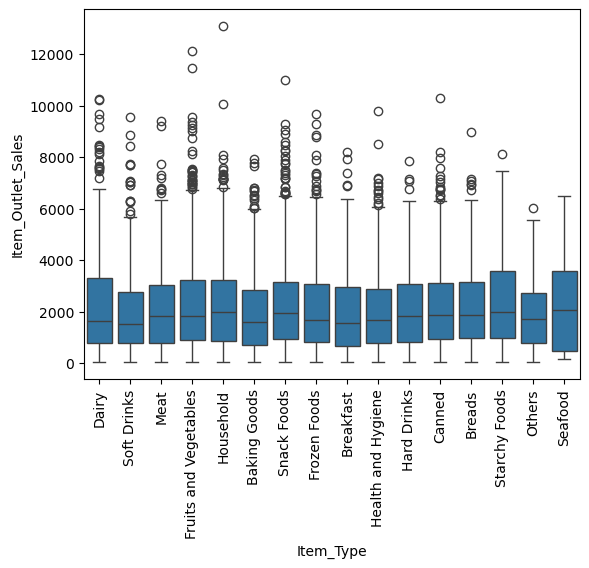

In [89]:
sns.boxplot(x=sales['Item_Type'],y=sales['Item_Outlet_Sales'],data=sales)
plt.xticks(rotation=90)
plt.show()

In [90]:
sales['Item_Type'].unique()

array(['Dairy', 'Soft Drinks', 'Meat', 'Fruits and Vegetables',
       'Household', 'Baking Goods', 'Snack Foods', 'Frozen Foods',
       'Breakfast', 'Health and Hygiene', 'Hard Drinks', 'Canned',
       'Breads', 'Starchy Foods', 'Others', 'Seafood'], dtype=object)

In [91]:
perishables=['Dairy', 'Soft Drinks', 'Meat', 'Fruits and Vegetables',
     'Snack Foods',
       'Breakfast',
       'Breads', 'Starchy Foods', 'Seafood']
perishables

['Dairy',
 'Soft Drinks',
 'Meat',
 'Fruits and Vegetables',
 'Snack Foods',
 'Breakfast',
 'Breads',
 'Starchy Foods',
 'Seafood']

In [92]:
def perish(x):
    if x in perishables:
        return 'perishables'
    else:
        return 'non-perishables'

In [93]:
sales['Item_Type']=sales['Item_Type'].apply(perish)

In [94]:
sales['Item_Type']

0           perishables
1           perishables
2           perishables
3           perishables
4       non-perishables
             ...       
8518        perishables
8519    non-perishables
8520    non-perishables
8521        perishables
8522        perishables
Name: Item_Type, Length: 8523, dtype: object

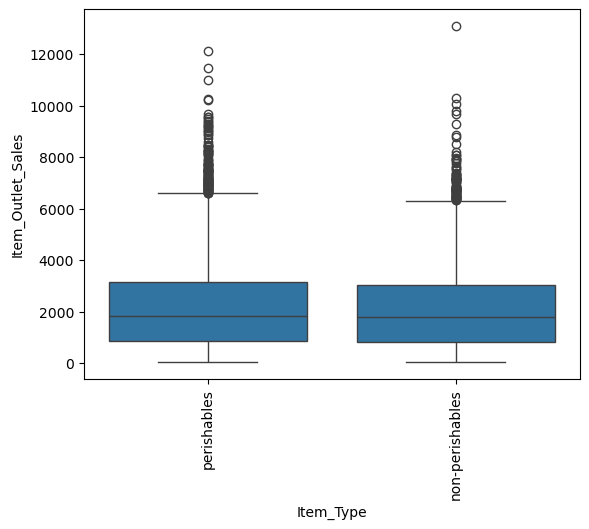

In [95]:
sns.boxplot(x=sales['Item_Type'],y=sales['Item_Outlet_Sales'],data=sales)
plt.xticks(rotation=90)
plt.show()

In [96]:
cat_cols

['Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

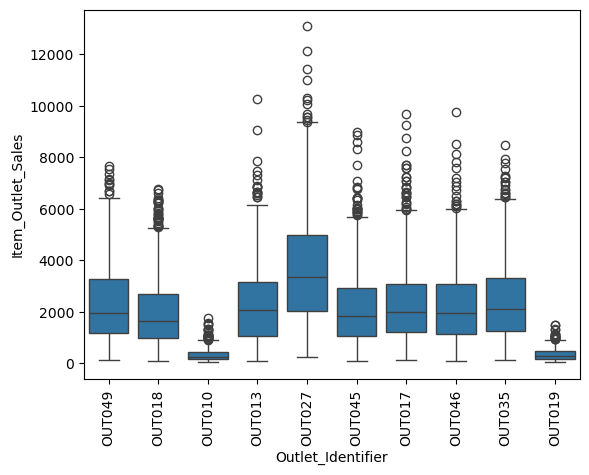

In [97]:
sns.boxplot(x=sales['Outlet_Identifier'],y=sales['Item_Outlet_Sales'],data=sales)
plt.xticks(rotation=90)
plt.show()

In [98]:
High = ['OUT013','OUT027']
Low = ['OUT010','OUT019']

In [99]:
def items(x):
    if x in High:
        return 'high'
    elif x in Low :
        return 'low'
    else:
        return 'Average'

In [100]:
items


<function __main__.items(x)>

In [101]:
sales['Outlet_Identifier']=sales['Outlet_Identifier'].apply(items)

In [102]:
sales['Outlet_Identifier']

0       Average
1       Average
2       Average
3           low
4          high
         ...   
8518       high
8519    Average
8520    Average
8521    Average
8522    Average
Name: Outlet_Identifier, Length: 8523, dtype: object

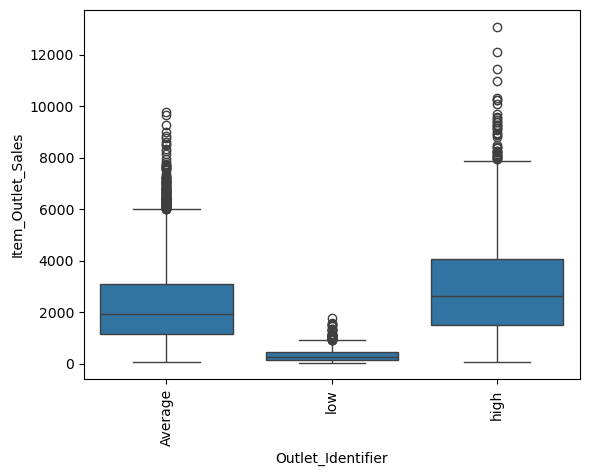

In [103]:
sns.boxplot(x=sales['Outlet_Identifier'],y=sales['Item_Outlet_Sales'],data=sales)
plt.xticks(rotation=90)
plt.show()

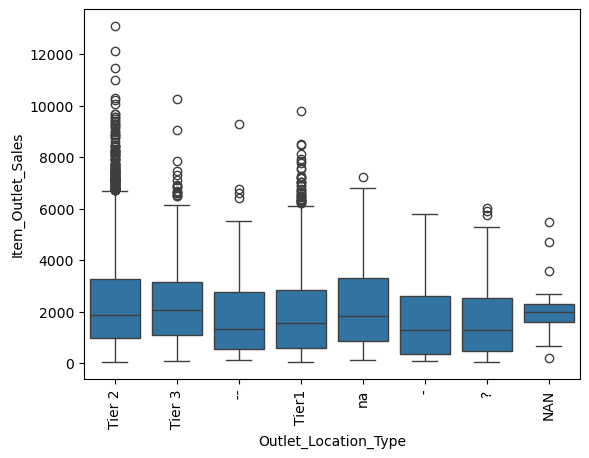

In [104]:
sns.boxplot(x=sales['Outlet_Location_Type'],y=sales['Item_Outlet_Sales'],data=sales)
plt.xticks(rotation=90)
plt.show()

In [105]:
sales['Outlet_Location_Type'].unique()

array(['Tier 2', 'Tier 3', '  --', 'Tier1', 'na', '  -', '?', 'NAN'],
      dtype=object)

In [106]:
Noise=['  --','na', '  -', '?', 'NAN']

In [107]:
sales['Outlet_Location_Type']=sales['Outlet_Location_Type'].replace(to_replace=Noise,value=["Missing"]*5)

In [108]:
sales['Outlet_Location_Type']

0       Tier 2
1       Tier 2
2       Tier 2
3       Tier 2
4       Tier 3
         ...  
8518    Tier 3
8519    Tier 2
8520     Tier1
8521    Tier 2
8522     Tier1
Name: Outlet_Location_Type, Length: 8523, dtype: object

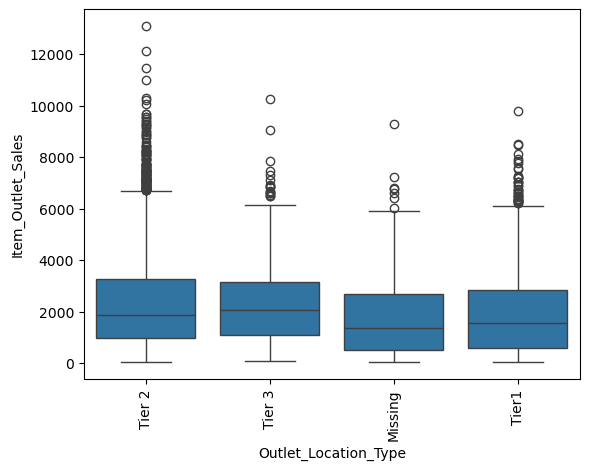

In [109]:
sns.boxplot(x=sales['Outlet_Location_Type'],y=sales['Item_Outlet_Sales'],data=sales)
plt.xticks(rotation=90)
plt.show()

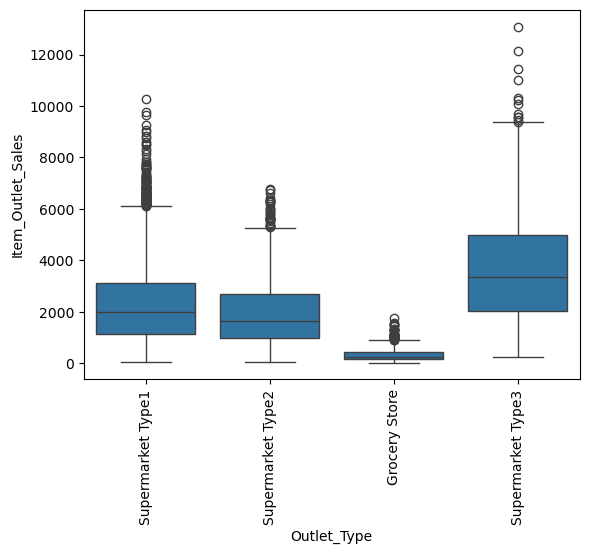

In [110]:
sns.boxplot(x=sales['Outlet_Type'],y=sales['Item_Outlet_Sales'],data=sales)
plt.xticks(rotation=90)
plt.show()

In [111]:
sales.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit,Ids
0,FDA15,9.30,Low Fat,0.016047,perishables,249.8,Average,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5,FD
1,DRC01,5.92,Regular,0.019278,perishables,48.3,Average,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3,DR
2,FDN15,14.58,Low Fat,0.016760,perishables,141.6,Average,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5,FD
3,FDX07,19.20,Regular,0.000000,perishables,182.1,low,1998,Medium,Tier 2,Grocery Store,732.3800,13.6,FD
4,NCD19,8.93,Non-Edible,0.000000,non-perishables,53.9,high,1987,High,Tier 3,Supermarket Type1,994.7052,14.1,NC


In [112]:
new_sales=sales.drop('Item_Identifier',axis=1)

In [113]:
new_sales

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit,Ids
0,9.30,Low Fat,0.016047,perishables,249.8,Average,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5,FD
1,5.92,Regular,0.019278,perishables,48.3,Average,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3,DR
2,14.58,Low Fat,0.016760,perishables,141.6,Average,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5,FD
3,19.20,Regular,0.000000,perishables,182.1,low,1998,Medium,Tier 2,Grocery Store,732.3800,13.6,FD
4,8.93,Non-Edible,0.000000,non-perishables,53.9,high,1987,High,Tier 3,Supermarket Type1,994.7052,14.1,NC
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,6.86,Low Fat,0.056783,perishables,214.5,high,1987,High,Tier 3,Supermarket Type1,2778.3834,14.1,FD
8519,8.38,Regular,0.046982,non-perishables,108.2,Average,2002,Medium,Tier 2,Supermarket Type1,549.2850,14.2,FD
8520,10.60,Non-Edible,0.035186,non-perishables,85.1,Average,2004,Small,Tier1,Supermarket Type1,1193.1136,9.5,NC
8521,7.21,Regular,0.145221,perishables,103.1,Average,2009,Medium,Tier 2,Supermarket Type2,1845.5976,14.2,FD


In [114]:
# sales.to_excel('C:/Users/user/Downloads/New_clean_dataset.xlsx', index=False)